In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from scipy.interpolate import UnivariateSpline
from patsy import dmatrix
np.random.seed(42)

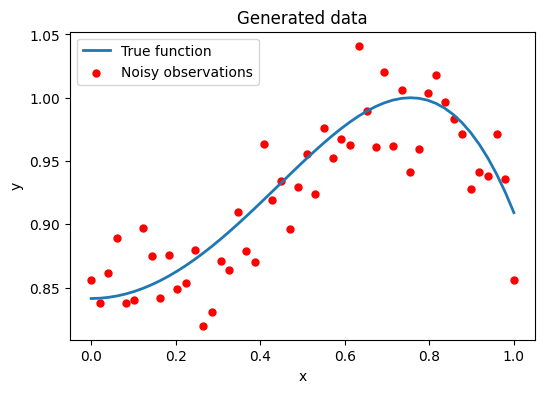

In [ ]:
N = 50
s = 0.03
x = np.linspace(0, 1, N)
y_true = np.sin(1 + x**2)
y_noise = y_true + np.random.normal(0, s, N)
plt.figure(figsize=(6, 4))
plt.plot(x, y_true, label="True function", linewidth=2)
plt.scatter(x, y_noise, color="red", s=25, label="Noisy observations")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Generated data")
plt.legend()
plt.show()


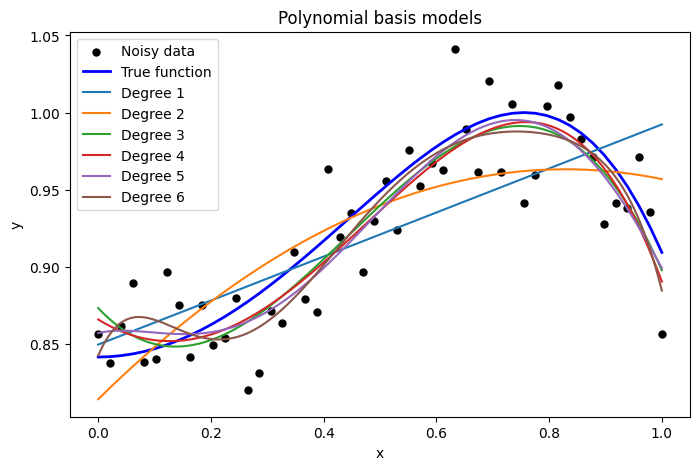

In [ ]:
plt.figure(figsize=(8, 5))
plt.scatter(x, y_noise, color="black", s=25, label="Noisy data")
plt.plot(x, y_true, color="blue", linewidth=2, label="True function")
x_grid = np.linspace(0, 1, 200).reshape(-1, 1)
for degree in range(1, 7):
 poly = PolynomialFeatures(degree=degree, include_bias=False)
 X_poly = poly.fit_transform(x.reshape(-1, 1))
 X_grid_poly = poly.transform(x_grid)
 model = LinearRegression()
 model.fit(X_poly, y_noise)
 y_pred = model.predict(X_grid_poly)
 plt.plot(x_grid, y_pred, linewidth=1.5, label=f"Degree {degree}")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Polynomial basis models")
plt.legend()
plt.show()

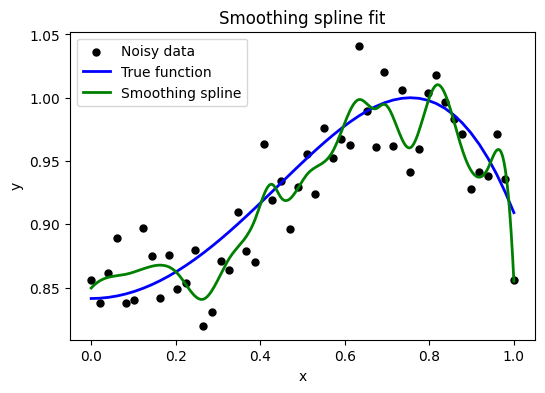

In [ ]:
spline = UnivariateSpline(x, y_noise, s=0.02)
x_smooth = np.linspace(0, 1, 300)
y_smooth = spline(x_smooth)
plt.figure(figsize=(6, 4))
plt.scatter(x, y_noise, color="black", s=25, label="Noisy data")
plt.plot(x, y_true, color="blue", linewidth=2, label="True function")
plt.plot(x_smooth, y_smooth, color="green", linewidth=2, label="Smoothing spline")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Smoothing spline fit")
plt.legend()
plt.show()

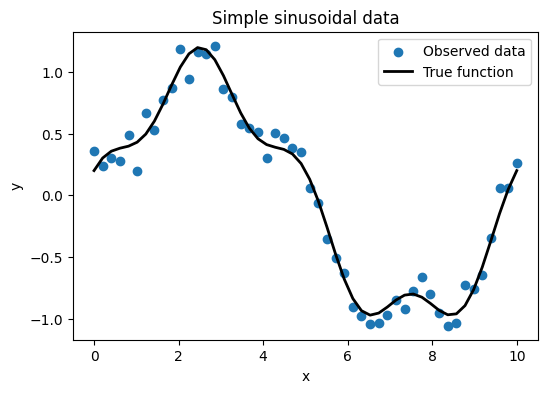

In [ ]:
np.random.seed(1)
x = np.linspace(0, 10, 50)
y_true = np.sin(np.pi * x / 5) + 0.2 * np.cos(4 * np.pi * x / 5)
y = y_true + np.random.normal(scale=0.1, size=len(x))
plt.figure(figsize=(6, 4))
plt.scatter(x, y, label="Observed data")
plt.plot(x, y_true, color="black", linewidth=2, label="True function")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Simple sinusoidal data")
plt.legend()
plt.show()

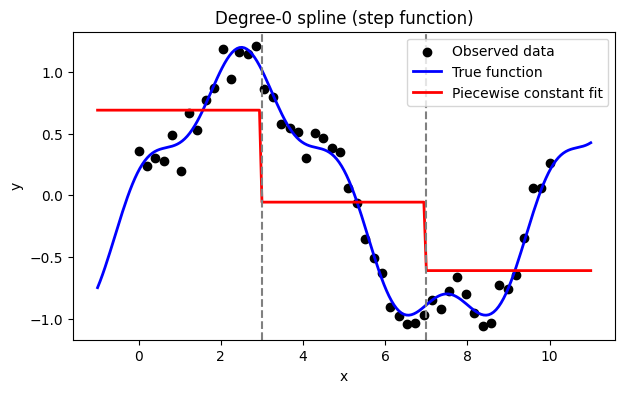

In [ ]:
xi = [3, 7]
def hc1(x):
 return (x < xi[0]).astype(int)
def hc2(x):
 return ((x >= xi[0]) & (x < xi[1])).astype(int)
def hc3(x):
 return (x >= xi[1]).astype(int)
H_c = np.column_stack([hc1(x), hc2(x), hc3(x)])
pc_fit = LinearRegression(fit_intercept=False)
pc_fit.fit(H_c, y)
xx = np.linspace(-1, 11, 199)
HH_c = np.column_stack([hc1(xx), hc2(xx), hc3(xx)])
yy_true = np.sin(np.pi * xx / 5) + 0.2 * np.cos(4 * np.pi * xx / 5)
yy_pred = pc_fit.predict(HH_c)
plt.figure(figsize=(7, 4))
plt.scatter(x, y, color="black", label="Observed data")
plt.plot(xx, yy_true, color="blue", linewidth=2, label="True function")
plt.plot(xx, yy_pred, color="red", linewidth=2, label="Piecewise constant fit")
plt.axvline(3, color="gray", linestyle="--")
plt.axvline(7, color="gray", linestyle="--")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Degree-0 spline (step function)")
plt.legend()
plt.show()

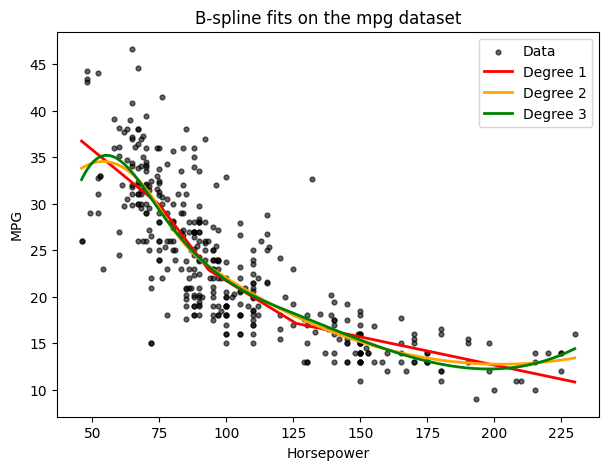

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from patsy import dmatrix
from sklearn.linear_model import LinearRegression
mpg = sns.load_dataset("mpg").dropna(subset=["horsepower", "mpg"])
x_real = mpg["horsepower"].values
y_real = mpg["mpg"].values
knots = np.quantile(x_real, [0.25, 0.5, 0.75])
x_grid = np.linspace(x_real.min(), x_real.max(), 300)
# Use SAME variable name: x
X_deg1 = dmatrix("bs(x, knots=knots, degree=1, include_intercept=False)",
{"x": x_real, "knots": knots}, return_type='dataframe')
X_deg2 = dmatrix("bs(x, knots=knots, degree=2, include_intercept=False)",
{"x": x_real, "knots": knots}, return_type='dataframe')
X_deg3 = dmatrix("bs(x, knots=knots, degree=3, include_intercept=False)",
{"x": x_real, "knots": knots}, return_type='dataframe')
grid_deg1 = dmatrix("bs(x, knots=knots, degree=1, include_intercept=False)",
{"x": x_grid, "knots": knots}, return_type='dataframe')
grid_deg2 = dmatrix("bs(x, knots=knots, degree=2, include_intercept=False)",
{"x": x_grid, "knots": knots}, return_type='dataframe')
grid_deg3 = dmatrix("bs(x, knots=knots, degree=3, include_intercept=False)",
{"x": x_grid, "knots": knots}, return_type='dataframe')
fit1 = LinearRegression().fit(X_deg1, y_real)
fit2 = LinearRegression().fit(X_deg2, y_real)
fit3 = LinearRegression().fit(X_deg3, y_real)
pred1 = fit1.predict(grid_deg1)
pred2 = fit2.predict(grid_deg2)
pred3 = fit3.predict(grid_deg3)
plt.figure(figsize=(7, 5))
plt.scatter(x_real, y_real, color="black", s=12, alpha=0.6, label="Data")
plt.plot(x_grid, pred1, color="red", linewidth=2, label="Degree 1")
plt.plot(x_grid, pred2, color="orange", linewidth=2, label="Degree 2")
plt.plot(x_grid, pred3, color="green", linewidth=2, label="Degree 3")
plt.xlabel("Horsepower")
plt.ylabel("MPG")
plt.title("B-spline fits on the mpg dataset")
plt.legend()
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.datasets import fetch_california_housing
from patsy import dmatrix

Feature range: 0.4999 15.0001


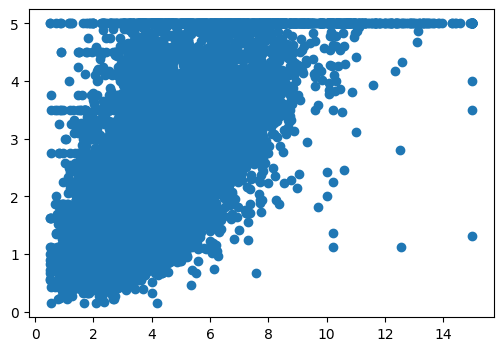

In [ ]:
california_housing = fetch_california_housing()
x = california_housing.data[:, 0]   # MedInc
y = california_housing.target       # House prices

plt.figure(figsize=(6, 4))
plt.scatter(x, y)
sorted_idx = np.argsort(x)
x = x[sorted_idx]
y = y[sorted_idx]

print("Feature range:", x.min(), x.max())

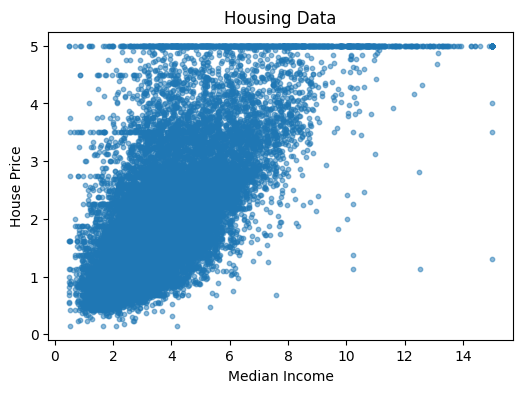

In [ ]:
plt.figure(figsize=(6, 4))
plt.scatter(x, y, s=10, alpha=0.5)
plt.xlabel("Median Income")
plt.ylabel("House Price")
plt.title("Housing Data")
plt.show()

In [ ]:
degree = 6



poly = PolynomialFeatures(degree=degree, include_bias=False)
X_poly = poly.fit_transform(x.reshape(-1, 1))

model_poly = LinearRegression()
model_poly.fit(X_poly, y)


x_grid = np.linspace(x.min(), x.max(), 300)
X_grid_poly = poly.transform(x_grid.reshape(-1, 1))
y_poly = model_poly.predict(X_grid_poly)

In [ ]:

knots = np.quantile(x, [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9])


X_spline = dmatrix(
    "bs(x, knots=knots, degree=3, include_intercept=False)",
    {"x": x, "knots": knots},
    return_type='dataframe'
)


model_spline = LinearRegression()
model_spline.fit(X_spline, y)

X_grid_spline = dmatrix(
    "bs(x, knots=knots, degree=3, include_intercept=False)",
    {"x": x_grid, "knots": knots},
    return_type='dataframe'
)

y_spline = model_spline.predict(X_grid_spline)

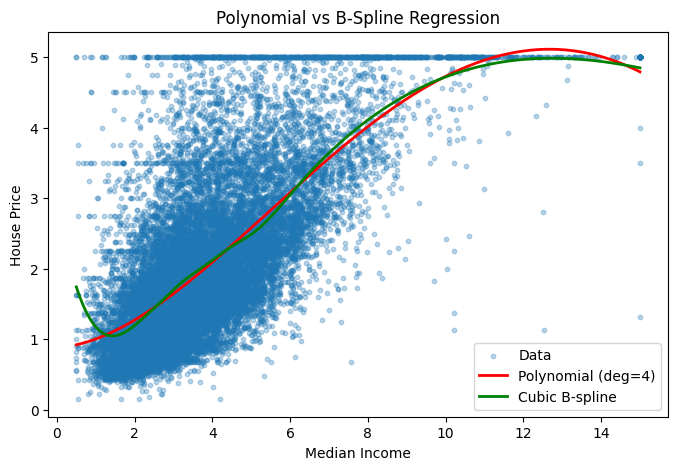

In [ ]:
plt.figure(figsize=(8, 5))

plt.scatter(x, y, s=10, alpha=0.3, label="Data")

plt.plot(x_grid, y_poly, color="red", linewidth=2, label=f"Polynomial (deg={degree})")
plt.plot(x_grid, y_spline, color="green", linewidth=2, label="Cubic B-spline")

plt.xlabel("Median Income")
plt.ylabel("House Price")
plt.title("Polynomial vs B-Spline Regression")
plt.legend()

plt.show()